OPTIMIZATION ALGORITHMS COMPARISON USING MNIST

TensorFlow Version : 2.20.0
NumPy Version      : 2.0.2

STEP 2: LOADING MNIST DATASET

Total Images : 70000
Image Shape  : (28, 28)
Number of Classes : 10

STEP 3: EXPLORATORY DATA ANALYSIS

Class-wise Distribution:
Digit 0 : 6903
Digit 1 : 7877
Digit 2 : 6990
Digit 3 : 7141
Digit 4 : 6824
Digit 5 : 6313
Digit 6 : 6876
Digit 7 : 7293
Digit 8 : 6825
Digit 9 : 6958


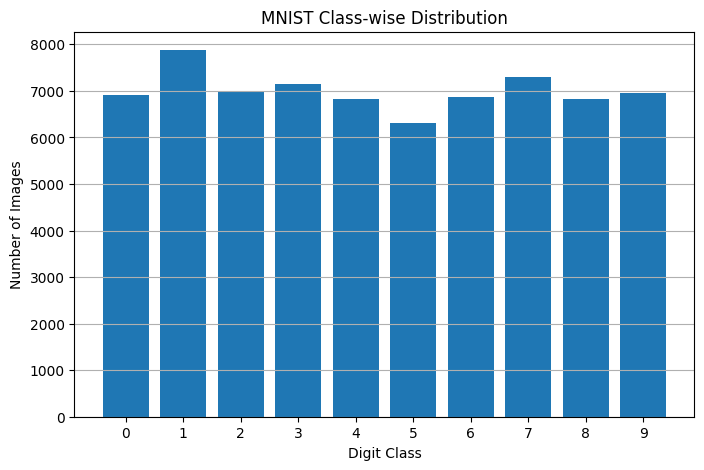

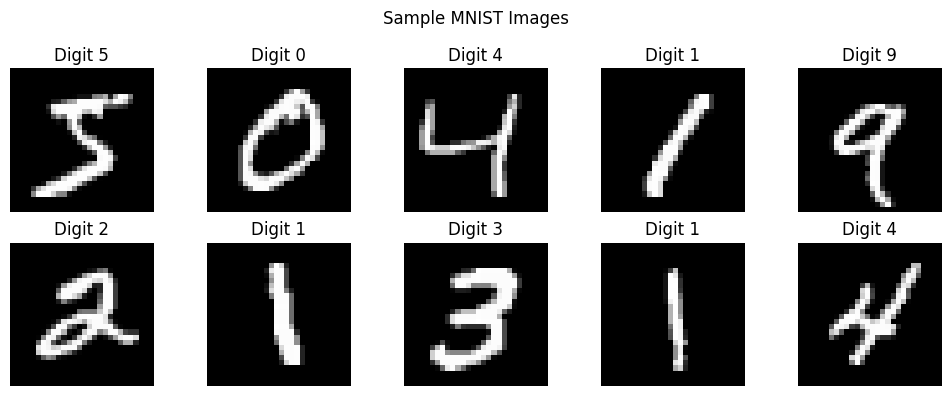


STEP 4: PREPROCESSING / STANDARDIZATION

Original Image Size : 28 x 28
Flattened Size      : 784
Pixel Range         : 0.0 to 1.0

STEP 5: TRAIN / VALIDATION / TEST SPLIT

Training Samples   : 56000
Validation Samples : 7000
Testing Samples    : 7000

Split Percentage:
Training   : 80%
Validation : 10%
Testing    : 10%

STEP 6: BUILDING MLP MODEL

MLP MODEL SUMMARY


Model: "sequential_127"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_381 (Dense)               │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_382 (Dense)               │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_383 (Dense)               │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)


Model Architecture:
Input Layer  : 784 neurons
Hidden Layer 1 : 128 neurons - ReLU
Hidden Layer 2 : 64 neurons  - ReLU
Output Layer : 10 neurons - Softmax


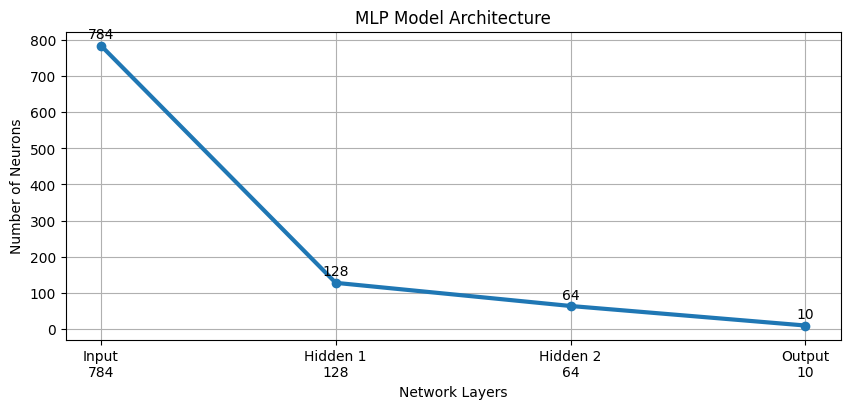


STEP 7: OPTIMIZATION ALGORITHMS

1. Gradient Descent (GD)
2. Momentum
3. RMSProp
4. Adam


STEP 8: TRAINING MODELS

----------------------------------------------------------------------
OPTIMIZER : GD
----------------------------------------------------------------------

Trial 1 of 10
Test Accuracy : 91.8 %
Complete Time : 6.87 seconds

Trial 2 of 10
Test Accuracy : 91.73 %
Complete Time : 9.44 seconds

Trial 3 of 10
Test Accuracy : 92.1 %
Complete Time : 9.77 seconds

Trial 4 of 10
Test Accuracy : 91.64 %
Complete Time : 8.35 seconds

Trial 5 of 10
Test Accuracy : 91.66 %
Complete Time : 8.71 seconds

Trial 6 of 10
Test Accuracy : 91.66 %
Complete Time : 7.24 seconds

Trial 7 of 10
Test Accuracy : 91.69 %
Complete Time : 9.17 seconds

Trial 8 of 10
Test Accuracy : 91.9 %
Complete Time : 8.41 seconds

Trial 9 of 10
Test Accuracy : 91.57 %
Complete Time : 8.73 seconds

Trial 10 of 10
Test Accuracy : 91.5 %
Complete Time : 8.24 seconds

Summary for GD
Best Accuracy : 92.1 %
Average Ac

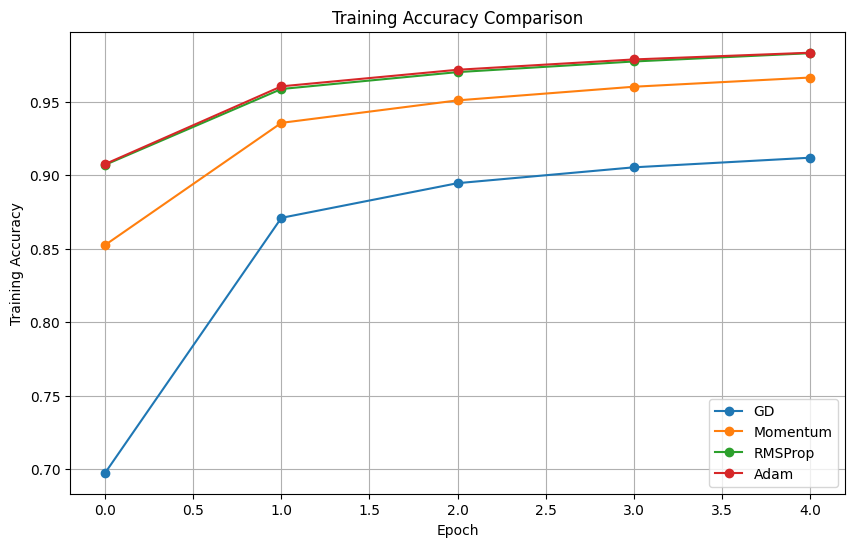


STEP 12: TESTING / VALIDATION ACCURACY COMPARISON


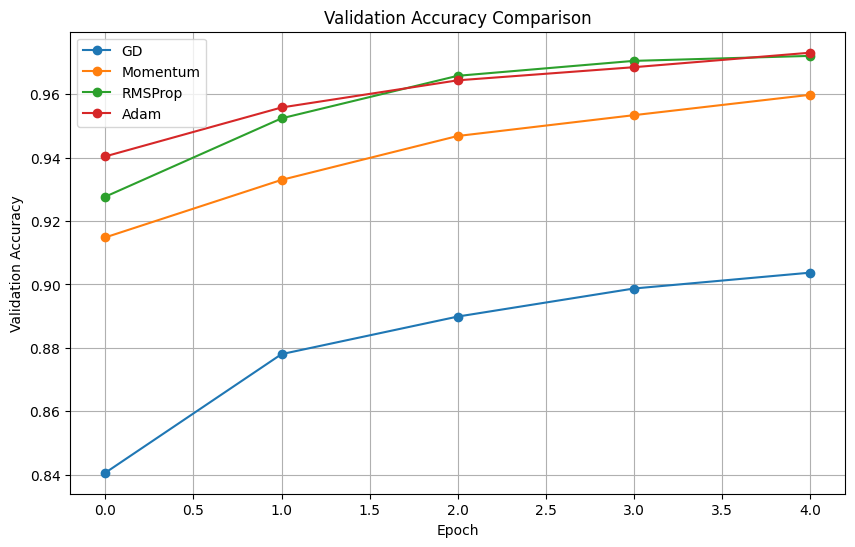


STEP 13: LOSS COMPARISON


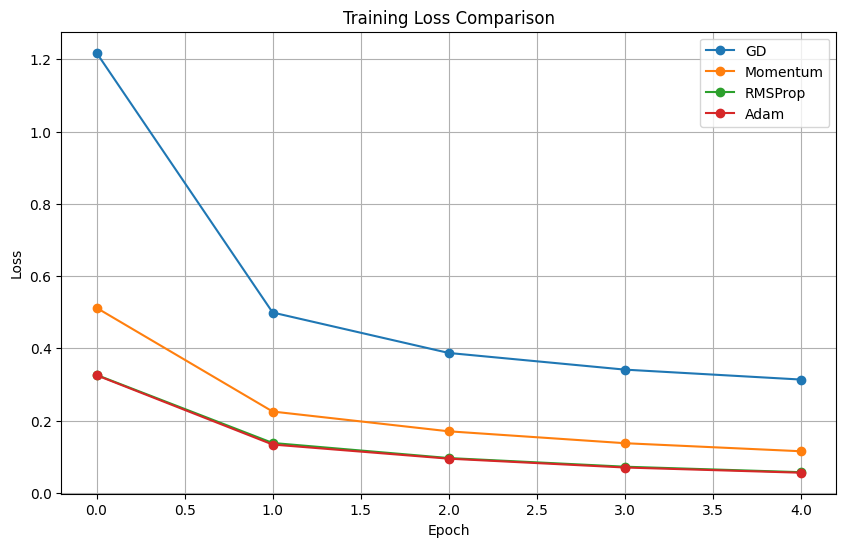


STEP 14: ACCURACY BAR GRAPH


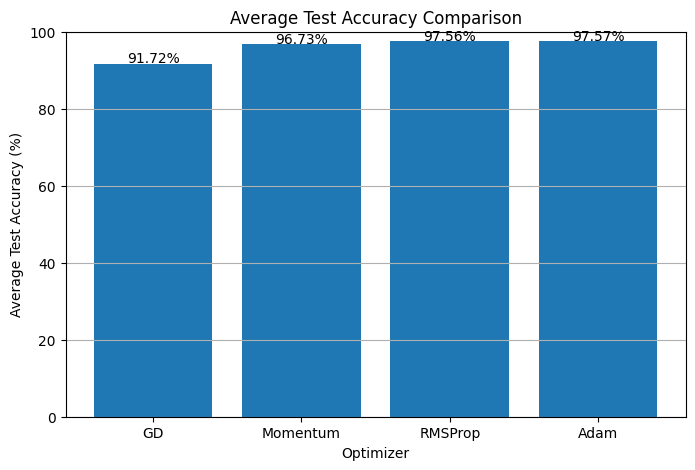


STEP 15: TRAINING TIME COMPARISON


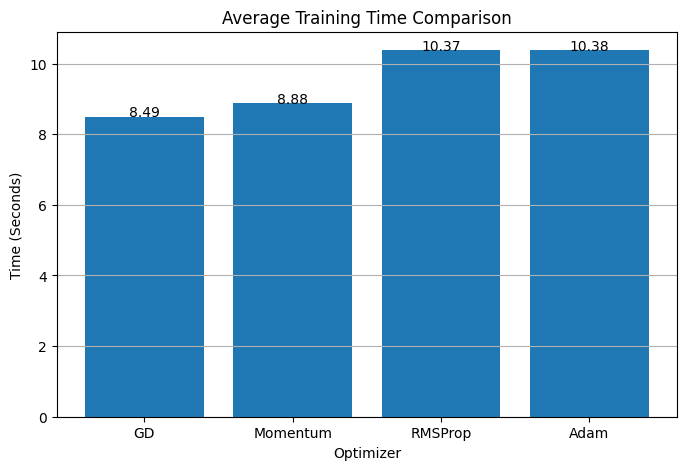


STEP 16: CONFUSION MATRIX COMPARISON


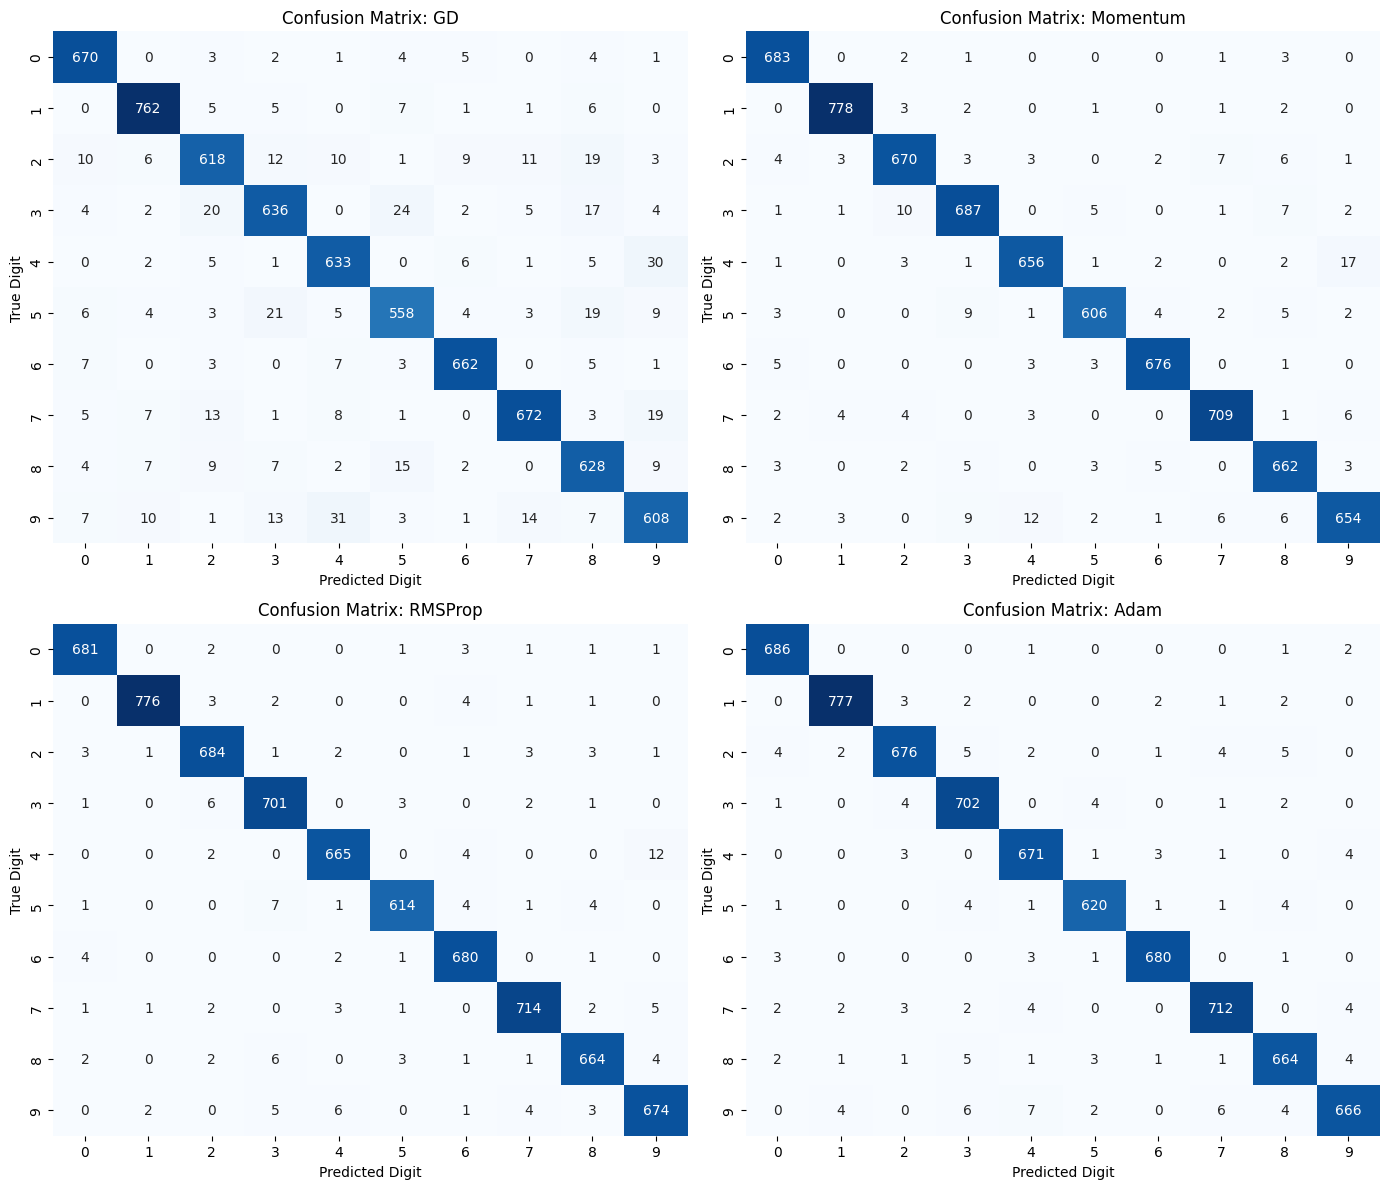


FINAL OPTIMIZER COMPARISON


Optimizer  Best Test Accuracy (%)  Average Test Accuracy (%)  Average Time (sec)  Rank
     Adam               97.914286                  97.570000           10.383914     1
  RMSProp               97.900000                  97.555714           10.372304     2
 Momentum               96.871429                  96.730000            8.882544     3
       GD               92.100000                  91.724286            8.493110     4

FINAL RESULT

Best Performing Optimizer : Adam
Fastest Optimizer : GD

Experiment Completed Successfully!


In [ ]:
# ============================================================
# EXPERIMENT:
# Implementation and Performance Comparison of Optimization
# Algorithms: GD, Momentum, RMSProp and Adam
# Dataset: MNIST
# ============================================================

# ------------------------------------------------------------
# STEP 1: IMPORT LIBRARIES
# ------------------------------------------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import time

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import SGD, RMSprop, Adam

print("=" * 70)
print("OPTIMIZATION ALGORITHMS COMPARISON USING MNIST")
print("=" * 70)

print("\nTensorFlow Version :", tf.__version__)
print("NumPy Version      :", np.__version__)

# ------------------------------------------------------------
# STEP 2: LOAD MNIST DATASET
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("STEP 2: LOADING MNIST DATASET")
print("=" * 70)

(X_train_original, y_train_original), (X_test_original, y_test_original) = \
    tf.keras.datasets.mnist.load_data()

# Combine original training and testing data
X = np.concatenate((X_train_original, X_test_original))
y = np.concatenate((y_train_original, y_test_original))

print("\nTotal Images :", X.shape[0])
print("Image Shape  :", X.shape[1:])
print("Number of Classes :", len(np.unique(y)))

# ------------------------------------------------------------
# STEP 3: EDA - CLASS-WISE DISTRIBUTION
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("STEP 3: EXPLORATORY DATA ANALYSIS")
print("=" * 70)

print("\nClass-wise Distribution:")

class_count = np.bincount(y)

for i in range(10):
    print("Digit", i, ":", class_count[i])

# Plot Class Distribution
plt.figure(figsize=(8, 5))
plt.bar(range(10), class_count)
plt.title("MNIST Class-wise Distribution")
plt.xlabel("Digit Class")
plt.ylabel("Number of Images")
plt.xticks(range(10))
plt.grid(axis='y')
plt.show()

# Display Sample Images
plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X[i], cmap='gray')
    plt.title("Digit " + str(y[i]))
    plt.axis("off")

plt.suptitle("Sample MNIST Images")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# STEP 4: PREPROCESS / STANDARDIZED DATA
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("STEP 4: PREPROCESSING / STANDARDIZATION")
print("=" * 70)

# Convert pixels from 0-255 to 0-1
X = X.astype("float32") / 255.0

# Flatten 28 x 28 images into 784 input features
X = X.reshape(X.shape[0], 784)

print("\nOriginal Image Size : 28 x 28")
print("Flattened Size      :", X.shape[1])
print("Pixel Range         :", X.min(), "to", X.max())

# ------------------------------------------------------------
# STEP 5: TRAIN / VALIDATION / TEST SPLIT
# 80% TRAIN, 10% VALIDATION, 10% TEST
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("STEP 5: TRAIN / VALIDATION / TEST SPLIT")
print("=" * 70)

# First split: 80% training and 20% temporary
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Second split: temporary into 10% validation and 10% testing
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("\nTraining Samples   :", X_train.shape[0])
print("Validation Samples :", X_val.shape[0])
print("Testing Samples    :", X_test.shape[0])

print("\nSplit Percentage:")
print("Training   : 80%")
print("Validation : 10%")
print("Testing    : 10%")

# ------------------------------------------------------------
# STEP 6: BUILD MLP MODEL
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("STEP 6: BUILDING MLP MODEL")
print("=" * 70)

def build_model(optimizer):

    model = Sequential([
        Input(shape=(784,)),

        Dense(128, activation="relu"),
        Dense(64, activation="relu"),

        Dense(10, activation="softmax")
    ])

    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


# ------------------------------------------------------------
# MODEL SUMMARY
# ------------------------------------------------------------

print("\nMLP MODEL SUMMARY")

temp_model = build_model(
    SGD(learning_rate=0.01)
)

temp_model.summary()

# ------------------------------------------------------------
# MODEL ARCHITECTURE GRAPH
# ------------------------------------------------------------

print("\nModel Architecture:")
print("Input Layer  : 784 neurons")
print("Hidden Layer 1 : 128 neurons - ReLU")
print("Hidden Layer 2 : 64 neurons  - ReLU")
print("Output Layer : 10 neurons - Softmax")

plt.figure(figsize=(10, 4))

layers = ["Input\n784", "Hidden 1\n128", "Hidden 2\n64", "Output\n10"]
neurons = [784, 128, 64, 10]

plt.plot(layers, neurons, marker="o", linewidth=3)
plt.title("MLP Model Architecture")
plt.xlabel("Network Layers")
plt.ylabel("Number of Neurons")
plt.grid(True)

for i in range(len(layers)):
    plt.text(i, neurons[i] + 20, str(neurons[i]),
             ha="center")

plt.show()

# ------------------------------------------------------------
# STEP 7: DEFINE OPTIMIZERS
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("STEP 7: OPTIMIZATION ALGORITHMS")
print("=" * 70)

print("""
1. Gradient Descent (GD)
2. Momentum
3. RMSProp
4. Adam
""")

# ------------------------------------------------------------
# TRAINING SETTINGS
# ------------------------------------------------------------

TRIALS = 10
EPOCHS = 5
BATCH_SIZE = 128

# Dictionaries to store results
results = []

histories = {}
best_models = {}

# ------------------------------------------------------------
# FUNCTION TO CREATE OPTIMIZER
# ------------------------------------------------------------

def get_optimizer(name):

    if name == "GD":

        return SGD(
            learning_rate=0.01
        )

    elif name == "Momentum":

        return SGD(
            learning_rate=0.01,
            momentum=0.9
        )

    elif name == "RMSProp":

        return RMSprop(
            learning_rate=0.001
        )

    elif name == "Adam":

        return Adam(
            learning_rate=0.001
        )


optimizers = [
    "GD",
    "Momentum",
    "RMSProp",
    "Adam"
]

# ------------------------------------------------------------
# STEP 8: TRAIN EACH OPTIMIZER 10 TIMES
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("STEP 8: TRAINING MODELS")
print("=" * 70)

for optimizer_name in optimizers:

    print("\n" + "-" * 70)
    print("OPTIMIZER :", optimizer_name)
    print("-" * 70)

    trial_accuracies = []
    trial_times = []

    best_accuracy = 0
    best_history = None
    best_trained_model = None

    for trial in range(1, TRIALS + 1):

        print("\nTrial", trial, "of", TRIALS)

        # Create optimizer
        optimizer = get_optimizer(optimizer_name)

        # Build a fresh model
        model = build_model(optimizer)

        # Start timer
        start_time = time.time()

        # Train model
        history = model.fit(
            X_train,
            y_train,
            validation_data=(X_val, y_val),
            epochs=EPOCHS,
            batch_size=BATCH_SIZE,
            verbose=0
        )

        # End timer
        end_time = time.time()

        complete_time = end_time - start_time

        # Test Prediction
        test_probability = model.predict(
            X_test,
            verbose=0
        )

        test_prediction = np.argmax(
            test_probability,
            axis=1
        )

        # Calculate Test Accuracy
        test_accuracy = accuracy_score(
            y_test,
            test_prediction
        )

        trial_accuracies.append(test_accuracy)
        trial_times.append(complete_time)

        print(
            "Test Accuracy :",
            round(test_accuracy * 100, 2),
            "%"
        )

        print(
            "Complete Time :",
            round(complete_time, 2),
            "seconds"
        )

        # Store best trial
        if test_accuracy > best_accuracy:

            best_accuracy = test_accuracy
            best_history = history
            best_trained_model = model

    # Store best history and trained model
    histories[optimizer_name] = best_history
    best_models[optimizer_name] = best_trained_model

    # Calculate average values
    average_accuracy = np.mean(trial_accuracies)
    average_time = np.mean(trial_times)

    best_trial_accuracy = np.max(trial_accuracies)

    # Store results
    results.append({
        "Optimizer": optimizer_name,
        "Best Test Accuracy (%)":
            best_trial_accuracy * 100,
        "Average Test Accuracy (%)":
            average_accuracy * 100,
        "Average Time (sec)":
            average_time
    })

    print("\nSummary for", optimizer_name)

    print(
        "Best Accuracy :",
        round(best_trial_accuracy * 100, 2),
        "%"
    )

    print(
        "Average Accuracy :",
        round(average_accuracy * 100, 2),
        "%"
    )

    print(
        "Average Time :",
        round(average_time, 2),
        "seconds"
    )


# ------------------------------------------------------------
# STEP 9: TABULAR SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("STEP 9: TABULAR SUMMARY")
print("=" * 70)

results_df = pd.DataFrame(results)

print("\n")
print(results_df.to_string(index=False))

# ------------------------------------------------------------
# STEP 10: COMPARE OPTIMIZERS
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("STEP 10: OPTIMIZER COMPARISON")
print("=" * 70)

best_accuracy_optimizer = results_df.loc[
    results_df["Average Test Accuracy (%)"].idxmax(),
    "Optimizer"
]

fastest_optimizer = results_df.loc[
    results_df["Average Time (sec)"].idxmin(),
    "Optimizer"
]

print(
    "\nHighest Average Test Accuracy :",
    best_accuracy_optimizer
)

print(
    "Fastest Optimizer :",
    fastest_optimizer
)

# ------------------------------------------------------------
# STEP 11: LEARNING CURVES - TRAINING ACCURACY
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("STEP 11: TRAINING ACCURACY COMPARISON")
print("=" * 70)

plt.figure(figsize=(10, 6))

for optimizer_name in optimizers:

    history = histories[optimizer_name]

    plt.plot(
        history.history["accuracy"],
        marker="o",
        label=optimizer_name
    )

plt.title("Training Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Training Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# ------------------------------------------------------------
# STEP 12: VALIDATION / TESTING ACCURACY
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("STEP 12: TESTING / VALIDATION ACCURACY COMPARISON")
print("=" * 70)

plt.figure(figsize=(10, 6))

for optimizer_name in optimizers:

    history = histories[optimizer_name]

    plt.plot(
        history.history["val_accuracy"],
        marker="o",
        label=optimizer_name
    )

plt.title("Validation Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# ------------------------------------------------------------
# STEP 13: LEARNING CURVES - LOSS
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("STEP 13: LOSS COMPARISON")
print("=" * 70)

plt.figure(figsize=(10, 6))

for optimizer_name in optimizers:

    history = histories[optimizer_name]

    plt.plot(
        history.history["loss"],
        marker="o",
        label=optimizer_name
    )

plt.title("Training Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

# ------------------------------------------------------------
# STEP 14: MODEL ACCURACY BAR GRAPH
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("STEP 14: ACCURACY BAR GRAPH")
print("=" * 70)

plt.figure(figsize=(8, 5))

plt.bar(
    results_df["Optimizer"],
    results_df["Average Test Accuracy (%)"]
)

plt.title("Average Test Accuracy Comparison")
plt.xlabel("Optimizer")
plt.ylabel("Average Test Accuracy (%)")
plt.ylim(0, 100)
plt.grid(axis="y")

for i, value in enumerate(
    results_df["Average Test Accuracy (%)"]
):

    plt.text(
        i,
        value + 0.2,
        f"{value:.2f}%",
        ha="center"
    )

plt.show()

# ------------------------------------------------------------
# STEP 15: TRAINING TIME COMPARISON
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("STEP 15: TRAINING TIME COMPARISON")
print("=" * 70)

plt.figure(figsize=(8, 5))

plt.bar(
    results_df["Optimizer"],
    results_df["Average Time (sec)"]
)

plt.title("Average Training Time Comparison")
plt.xlabel("Optimizer")
plt.ylabel("Time (Seconds)")
plt.grid(axis="y")

for i, value in enumerate(
    results_df["Average Time (sec)"]
):

    plt.text(
        i,
        value,
        f"{value:.2f}",
        ha="center"
    )

plt.show()

# ------------------------------------------------------------
# STEP 16: CONFUSION MATRIX COMPARISON
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("STEP 16: CONFUSION MATRIX COMPARISON")
print("=" * 70)

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for idx, optimizer_name in enumerate(optimizers):

    model = best_models[optimizer_name]

    test_probability = model.predict(X_test, verbose=0)
    test_prediction = np.argmax(test_probability, axis=1)

    cm = confusion_matrix(y_test, test_prediction)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=axes[idx],
        cbar=False
    )

    axes[idx].set_title(f"Confusion Matrix: {optimizer_name}")
    axes[idx].set_xlabel("Predicted Digit")
    axes[idx].set_ylabel("True Digit")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# STEP 17: FINAL COMPARISON TABLE
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("FINAL OPTIMIZER COMPARISON")
print("=" * 70)

final_table = results_df.copy()

final_table["Rank"] = final_table[
    "Average Test Accuracy (%)"
].rank(
    ascending=False,
    method="min"
).astype(int)

final_table = final_table.sort_values("Rank")

print("\n")
print(final_table.to_string(index=False))

# ------------------------------------------------------------
# STEP 18: FINAL RESULT
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("FINAL RESULT")
print("=" * 70)

print(
    "\nBest Performing Optimizer :",
    best_accuracy_optimizer
)

print(
    "Fastest Optimizer :",
    fastest_optimizer
)

print("\nExperiment Completed Successfully!")
print("=" * 70)